# Color Detection - 02: Named Colours Across Images

Compare the dominant palette of several images and map each centre to the nearest named colour.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils

## 1. Side-by-side palettes

/Users/tkarim45/miniconda3/envs/personal/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


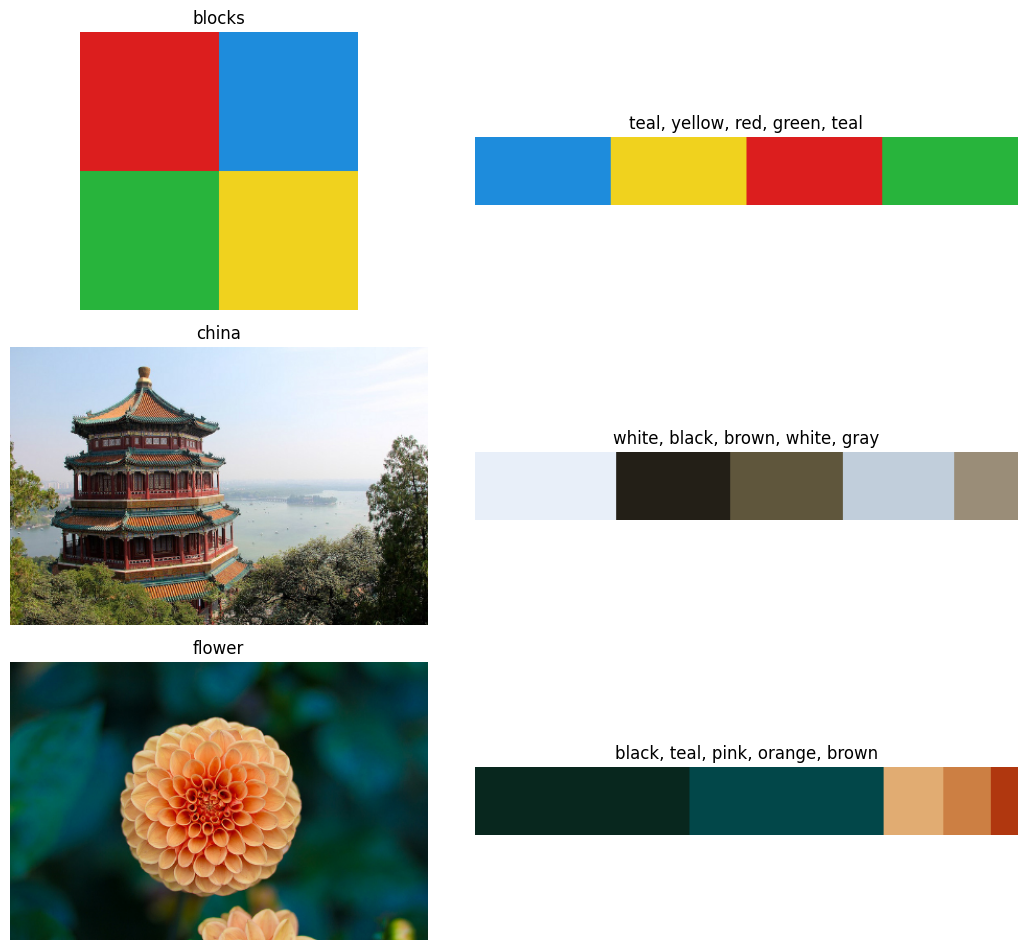

In [2]:
imgs = {'blocks':'data/blocks.png', 'china':'data/china.png', 'flower':'data/flower.png'}
fig, ax = plt.subplots(len(imgs), 2, figsize=(11, 3.2*len(imgs)))
for row,(name,path) in enumerate(imgs.items()):
    im = utils.load_image(path)
    centers, props = utils.dominant_colors(im, k=5)
    ax[row,0].imshow(im); ax[row,0].set_title(name); ax[row,0].axis('off')
    ax[row,1].imshow(utils.palette_strip(centers, props)); ax[row,1].axis('off')
    ax[row,1].set_title(', '.join(utils.closest_color_name(c) for c in centers))
plt.tight_layout(); plt.show()

## 2. Full named breakdown for the flower photo

In [3]:
flower = utils.load_image('data/flower.png')
centers, props = utils.dominant_colors(flower, k=6)
print('%-18s %-8s %s' % ('RGB','share','nearest name'))
for c,p in zip(centers,props):
    print('%-18s %-8.2f %s' % (str(tuple(int(v) for v in c)), p, utils.closest_color_name(c)))

RGB                share    nearest name
(6, 55, 49)        0.32     black
(8, 30, 20)        0.22     black
(1, 79, 82)        0.21     teal
(225, 172, 115)    0.11     pink
(204, 128, 68)     0.09     orange
(176, 56, 15)      0.05     brown


### Finding
On the synthetic blocks the names are exact. On photos the nearest-name mapping is only as good as the 18-colour reference palette: a muted olive-green leaf can land on 'green' or 'olive' depending on lighting, and near-white highlights collapse to 'white' / 'gray'. Dominant-colour extraction is solid; human colour naming is the fuzzy part.